In [2]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

In [3]:
from sklearn import datasets  # for machine learning models
iris = datasets.load_iris()
# The dataset has 150 samples,
#  with four features (the measurements)
#  and three labels (the flower types).
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

This is a classification problem since we are trying to predict the categorical label (flower type) based on the features

In [6]:
x = iris.data # features
y = iris.target # labels

x.shape, x.dtype
y.shape, y.dtype

((150,), dtype('int32'))

In [12]:
features = iris.feature_names
targets = iris.target_names.tolist()

features, targets

(['sepal length (cm)',
  'sepal width (cm)',
  'petal length (cm)',
  'petal width (cm)'],
 ['setosa', 'versicolor', 'virginica'])

Confusion Matrix:

To evaluate the model's performance, a confusion matrix is used. This matrix shows where the model made mistakes by comparing the actual flower type with the predicted flower type.
For instance, Setosa flowers were always classified correctly, but some mistakes were made between Versicolor and Virginica flowers.

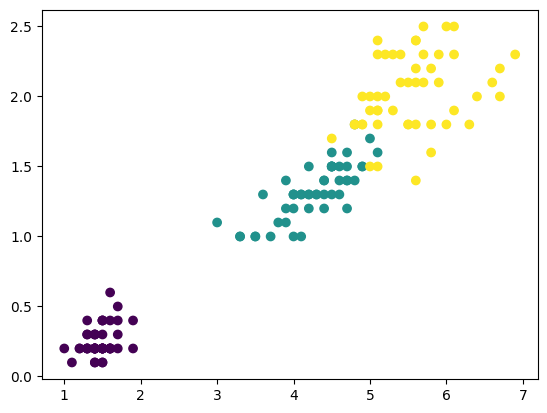

In [13]:
plt.scatter(x[:,2], x[:, 3], c = y)

What below code does: 

This imports the Linear Discriminant Analysis (LDA) class from Scikit-learn. LDA is a classification algorithm used to find a linear combination of features that best separates two or more classes of objects (in this case, the types of iris flowers).

How below code's used: 

After importing, the LDA model is instantiated by calling LinearDiscriminantAnalysis(), creating a model object that will be trained on data.

In [14]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
model = LinearDiscriminantAnalysis()



LinearDiscriminantAnalysis()

What it does: 

The fit() method is used to train the LDA model with data.

x: This is the feature matrix (e.g., sepal length, petal width), which contains the information used to predict the flower type.

y: This is the label array, which contains the actual categories (types of flowers) for each sample.

How it's used: 

The model learns the relationship between the features (x) and the labels (y), essentially "learning" how to classify new flowers based on their features.

In [ ]:
model.fit(x, y)

What it does: 

The predict() method is used to make predictions after the model has been trained.

Here, it takes the same feature data (x) as input and predicts the labels (y_pred), based on the patterns learned during training.

How it's used: 

y_pred will be an array of predicted flower types for each row of x. Ideally, these predictions should be close or identical to the actual labels (y) if the model is accurate.

In [15]:
y_pred = model.predict(x)


,0
0,0
0,0
0,0
0,0
0,0
...,...
2,2
2,2
2,2
2,2


What it does: 

This creates a pandas DataFrame to display both the actual values (y) and the predicted values (y_pred) side by side.

How it's used: 

This allows you to easily compare how well the model's predictions (y_pred) match the true values (y). You’ll be able to see where the model made mistakes (i.e., when y and y_pred don’t match).

In [ ]:
pd.DataFrame(y, y_pred)

What it does: 

The confusion_matrix() function computes the confusion matrix, which is a table that shows how well the classification model performed.

It compares the true labels (y) with the predicted labels (y_pred) and shows where the model made correct and incorrect predictions.

How it's used: 

conf_mat is a matrix where the rows represent the actual classes, and the columns represent the predicted classes. For example, if a flower of type "Setosa" was predicted as "Versicolor", this error will be captured in the confusion matrix.

In [16]:
from sklearn.metrics import confusion_matrix
conf_mat = confusion_matrix(y, y_pred)
conf_mat

array([[50,  0,  0],
       [ 0, 48,  2],
       [ 0,  1, 49]], dtype=int64)

What it does: 

ConfusionMatrixDisplay() creates a visual representation of the confusion matrix.

conf_mat: The confusion matrix computed earlier.
display_labels=targets: This labels the matrix axes with the flower types (e.g., Setosa, Versicolor, Virginica).

How it's used: 

.plot() generates a heatmap-like plot of the confusion matrix, making it easier to visually identify where the model made mistakes and where it performed well.

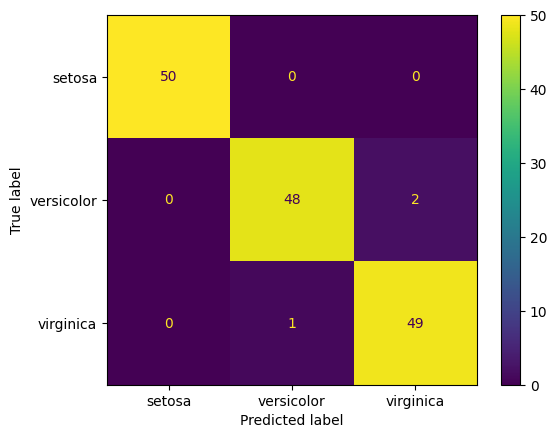

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay(conf_mat, display_labels=targets).plot()

Let's interpret the confusion matrix plot you’ve uploaded.

### Key Components of the Confusion Matrix Plot:

1. **True Labels (Vertical Axis)**: This represents the **actual classes** (the real types of flowers) in the dataset. The three rows correspond to the three flower types: **Setosa**, **Versicolor**, and **Virginica**.

2. **Predicted Labels (Horizontal Axis)**: This shows the **predicted classes** (the flower types predicted by the machine learning model). The three columns correspond to the predicted flower types: **Setosa**, **Versicolor**, and **Virginica**.

3. **Diagonal Values**: The numbers on the diagonal (from top-left to bottom-right) indicate the correct predictions, where the true label matches the predicted label.

4. **Off-Diagonal Values**: The numbers outside the diagonal represent the model's errors or misclassifications, where the true label does not match the predicted label.

---

### Breakdown of the Plot:

#### 1. **Setosa Predictions** (Top Row):
   - **50 correct predictions**: The model predicted 50 flowers as Setosa, and all 50 were truly Setosa.
   - **No errors**: The model made no mistakes in classifying Setosa flowers.

#### 2. **Versicolor Predictions** (Middle Row):
   - **48 correct predictions**: The model predicted 48 flowers correctly as Versicolor.
   - **2 errors**: The model mistakenly classified 2 Versicolor flowers as Virginica.

#### 3. **Virginica Predictions** (Bottom Row):
   - **49 correct predictions**: The model predicted 49 flowers correctly as Virginica.
   - **1 error**: The model mistakenly classified 1 Virginica flower as Versicolor.

---

### General Model Performance:

- **High Accuracy**: The model performs very well, as almost all flowers were correctly classified. Only 3 out of 150 predictions were incorrect.
   - **Setosa**: Perfect classification (100% accuracy).
   - **Versicolor**: 48 correct out of 50, with 2 misclassified as Virginica.
   - **Virginica**: 49 correct out of 50, with 1 misclassified as Versicolor.

### Summary:
- The model achieves excellent accuracy (around 98%), as indicated by only 3 misclassifications in total. Most errors occur between **Versicolor** and **Virginica**, which suggests that these two classes have overlapping or similar feature spaces, making them slightly harder to distinguish.

This confusion matrix shows that the model works very well, but there is some minor confusion between Versicolor and Virginica flowers.

Although this demo shows how easy it is to create and use a machine learning model, real-world analysis requires more rigor, such as cross-validation, hyperparameter tuning, and careful error analysis.